In [81]:
import pandas as pd
import numpy as np

df = pd.read_csv('football.csv')

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8925 entries, 0 to 8924
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   matchId                8925 non-null   object 
 1   playerId               8925 non-null   object 
 2   playType               8925 non-null   object 
 3   bodyPart               8925 non-null   object 
 4   x                      8925 non-null   float64
 5   y                      8925 non-null   float64
 6   interveningOpponents   8925 non-null   int64  
 7   interveningTeammates   8925 non-null   int64  
 8   interferenceOnShooter  8891 non-null   object 
 9   minute                 8925 non-null   int64  
 10  second                 8925 non-null   int64  
 11  outcome                8891 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 836.8+ KB
None
                 x            y  interveningOpponents  interveningTeammates  \
count  8925.00000

c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


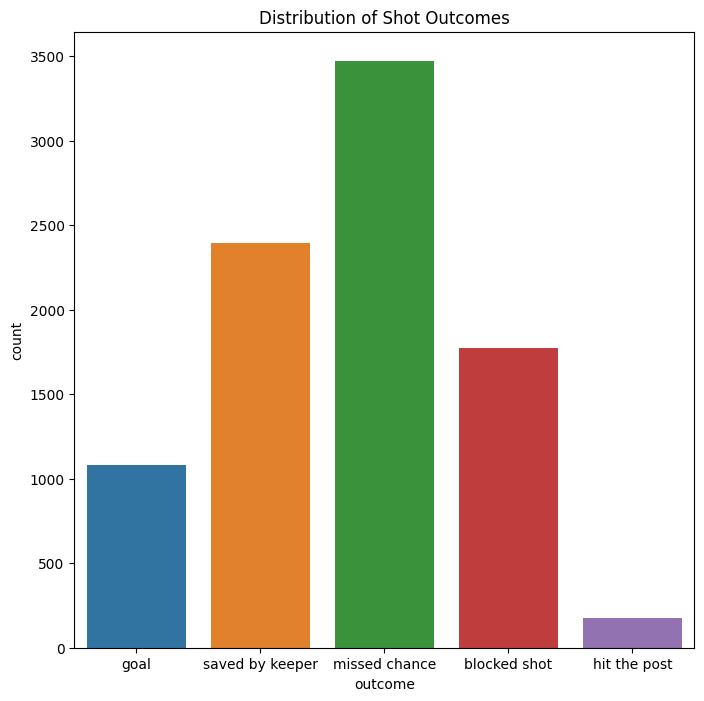

c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


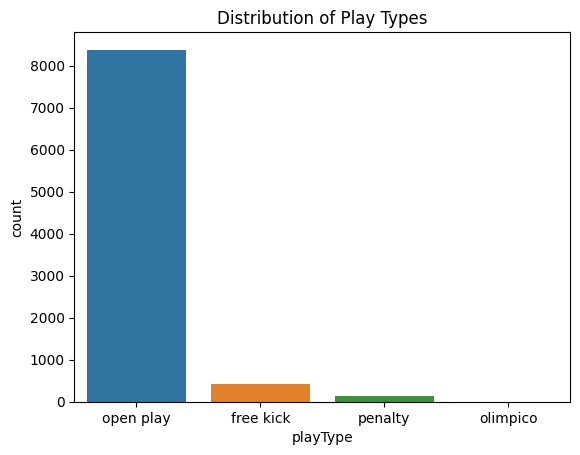

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of shot outcomes
plt.figure(figsize=(8, 8))
sns.countplot(x='outcome', data=df)
plt.title('Distribution of Shot Outcomes')
plt.show()

# Visualize the distribution of play types
sns.countplot(x='playType', data=df)
plt.title('Distribution of Play Types')
plt.show()

In [83]:
df['outcome'] = df['outcome'].replace({'own goal': 'goal'})
df['outcome'] = (df['outcome'] == 'goal')

In [84]:
df['matchId'] = df['matchId'].str.extract('(\d+)').astype(int)
df['playerId'] = df['playerId'].str.extract('(\d+)').astype(int)

In [85]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
categorical_columns = ['playType', 'bodyPart', 'interferenceOnShooter']
df_numeric = df.copy()
for col in categorical_columns:
    df_numeric[col] = label_encoder.fit_transform(df_numeric[col])
    print("Classes:", label_encoder.classes_)

Classes: ['free kick' 'olimpico' 'open play' 'penalty']
Classes: ['head' 'left foot' 'other' 'right foot']
Classes: ['high' 'low' 'medium' nan]


In [86]:
df

,matchId,playerId,playType,bodyPart,x,y,interveningOpponents,interveningTeammates,interferenceOnShooter,minute,second,outcome
0,91,103,open play,right foot,13.47,-11.22,1,0,medium,70,9,True
1,17,16,open play,left foot,9.48,14.22,3,0,medium,55,4,False
2,111,88,free kick,left foot,29.43,-1.25,6,2,low,86,31,False
3,142,87,open play,right foot,26.93,1.00,4,1,medium,77,2,False
4,117,9,open play,right foot,10.72,5.24,2,0,medium,76,46,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8920,57,115,open play,head,6.48,3.99,3,0,high,69,50,False
8921,59,76,open play,right foot,21.45,-8.73,4,1,medium,15,53,False
8922,55,150,open play,left foot,11.97,3.24,3,0,medium,84,34,False
8923,33,130,open play,right foot,6.48,-6.98,1,0,high,4,39,False


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

X = df_numeric.drop(columns=['outcome'])
y = df_numeric['outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model
print(f'Accuracy before feature engineering: {accuracy_score(y_test, y_pred)}')

Accuracy before feature engineering: 0.8913368185212845


In [99]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': mutual_info})

# Sort the DataFrame by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the results
print(feature_importance)

                 Feature  Importance
2                      x    0.036103
4   interveningOpponents    0.035253
3                      y    0.029684
0               playType    0.021837
5   interveningTeammates    0.010140
1               bodyPart    0.000000
6  interferenceOnShooter    0.000000
7                 minute    0.000000
8                 second    0.000000


After

In [92]:
# Fill nulls with 'low' where interveningOpponents is 0
df_numeric.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] == 0), 'interferenceOnShooter'] = 1 #'low'

# Fill nulls with 'medium' where interveningOpponents is 1
df_numeric.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] == 1), 'interferenceOnShooter'] = 2 #'medium'

# Fill nulls with 'high' where interveningOpponents is 2 or more
df_numeric.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] > 1), 'interferenceOnShooter'] = 0 #'high'


In [93]:
most_frequent_value = df_numeric['outcome'].mode()[0]
df_numeric['outcome'].fillna(most_frequent_value, inplace=True)

In [94]:
df_numeric['bodyPart'].replace({'right foot': 'foot', 'left foot': 'foot'}, inplace=True)

In [95]:
df

,matchId,playerId,playType,bodyPart,x,y,interveningOpponents,interveningTeammates,interferenceOnShooter,minute,second,outcome
0,91,103,open play,right foot,13.47,-11.22,1,0,medium,70,9,True
1,17,16,open play,left foot,9.48,14.22,3,0,medium,55,4,False
2,111,88,free kick,left foot,29.43,-1.25,6,2,low,86,31,False
3,142,87,open play,right foot,26.93,1.00,4,1,medium,77,2,False
4,117,9,open play,right foot,10.72,5.24,2,0,medium,76,46,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8920,57,115,open play,head,6.48,3.99,3,0,high,69,50,False
8921,59,76,open play,right foot,21.45,-8.73,4,1,medium,15,53,False
8922,55,150,open play,left foot,11.97,3.24,3,0,medium,84,34,False
8923,33,130,open play,right foot,6.48,-6.98,1,0,high,4,39,False


In [41]:
#df_numeric = df.copy()
#categorical_columns = ['playType', 'bodyPart', 'interferenceOnShooter', 'outcome']

# Use pd.get_dummies for one-hot encoding
#df_numeric = pd.get_dummies(df, columns=categorical_columns)

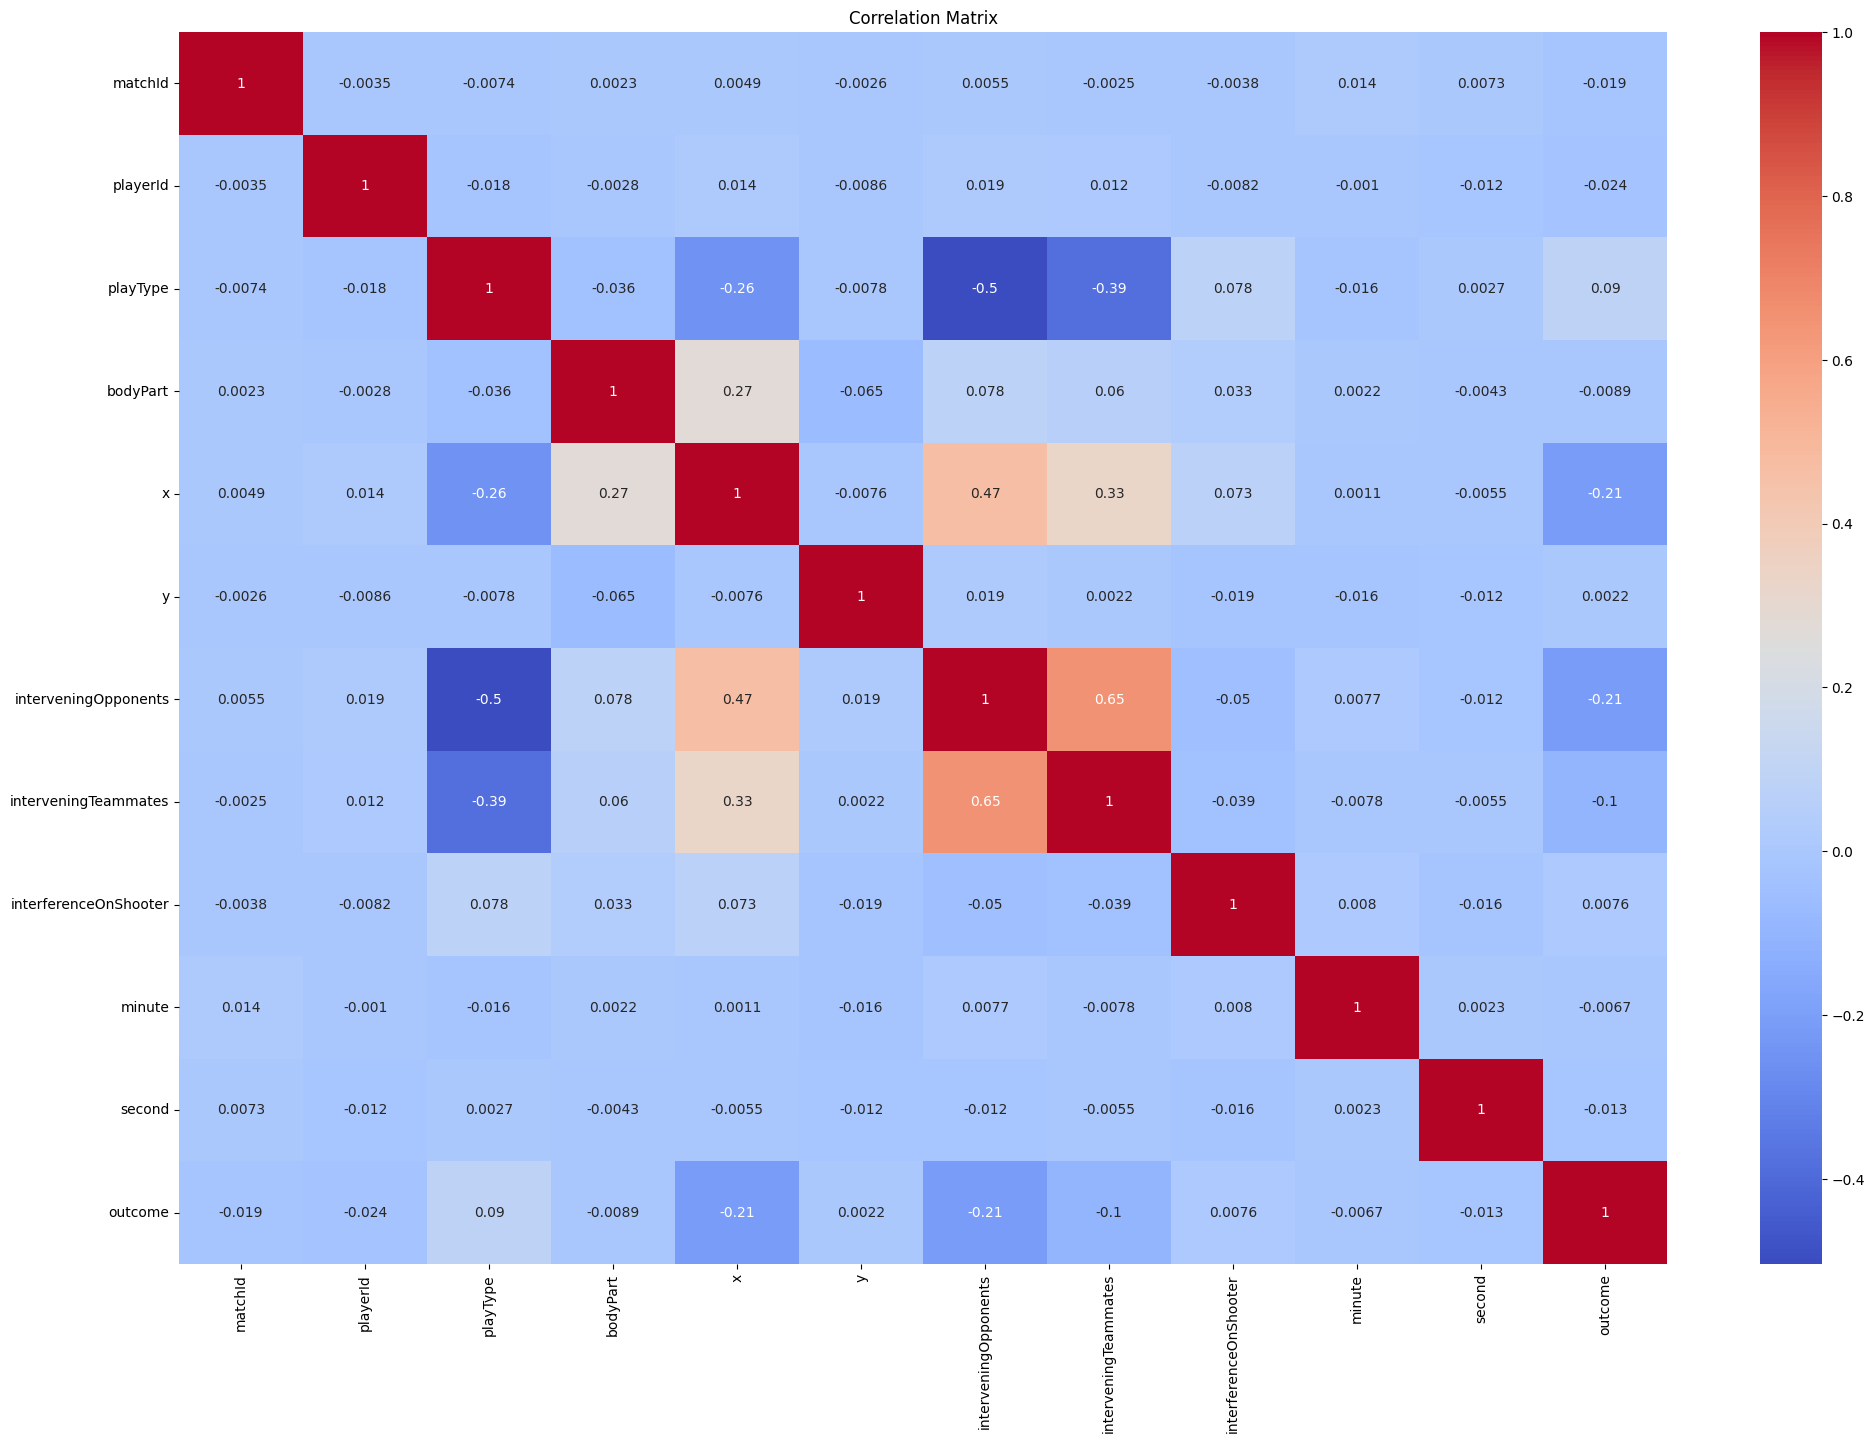

In [96]:
# Check correlations between numeric features
#plt.figure(figsize=(12, 8)) 
plt.figure(figsize=(24, 16)) 
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [100]:
#low_importance_features = feature_importance[feature_importance['Importance'] < 0.01]['Feature']
#df_numeric.drop(columns=low_importance_features, inplace=True)
df_numeric.drop(columns=['matchId', 'playerId'], inplace=True)

In [101]:
df_numeric['distance'] = np.sqrt(df_numeric['x']**2 + df_numeric['y']**2)

In [102]:
# Enhance Distance Calculation
df_numeric['angle'] = np.arctan2(df_numeric['y'], df_numeric['x'])  # Calculate angle

# Combine Opponents and Teammates
#df['intervening_players'] = df['interveningOpponents'] + df['interveningTeammates']

# Select Top Features for Modeling
#top_features = ['distance', 'interveningOpponents', 'x', 'y', 'angle']
#X = df_numeric[top_features]
y = df_numeric['outcome']

# Train a model using the selected features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [103]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': mutual_info})

# Sort the DataFrame by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the results
print(feature_importance)

                 Feature  Importance
4   interveningOpponents    0.041066
2                      x    0.032095
3                      y    0.031601
0               playType    0.021674
5   interveningTeammates    0.012755
1               bodyPart    0.007193
6  interferenceOnShooter    0.007066
8                 second    0.001532
7                 minute    0.001251


In [104]:
print(df_numeric)

      playType  bodyPart      x      y  interveningOpponents  \
0            2         3  13.47 -11.22                     1   
1            2         1   9.48  14.22                     3   
2            0         1  29.43  -1.25                     6   
3            2         3  26.93   1.00                     4   
4            2         3  10.72   5.24                     2   
...        ...       ...    ...    ...                   ...   
8920         2         0   6.48   3.99                     3   
8921         2         3  21.45  -8.73                     4   
8922         2         1  11.97   3.24                     3   
8923         2         3   6.48  -6.98                     1   
8924         2         3   8.23  26.43                     2   

      interveningTeammates interferenceOnShooter  minute  second  outcome  \
0                        0                     2      70       9     True   
1                        0                     2      55       4    False   


In [105]:
y_pred = clf.predict(X_test)

# Evaluate the model
print(f'Accuracy after feature engineering: {accuracy_score(y_test, y_pred)}')

Accuracy after feature engineering: 0.8857142857142857
